# Speech/silence discrimantion approach using Dual-Threshold Endpoint Detection technique.

This notebook covers the pipeline for the process.

Below cover each step that the program execute to reach the desired outputs.

# 1. Modules import and constant declarations.

This section cover the necessary modules that are needed for the program to work correctly (audio processing, array manipulation and plotting).

It also defines constants that are used throughout the execution of the program.

In [1]:
%matplotlib inline
import os
import wave
import math
import numpy as np
import matplotlib.pyplot as pyplot

# Define global constants for frame processing based on acoustic properties.
# FRAME_SIZE and FRAME_STEP are in milliseconds. MIN_SILENCE defines the 
# minimum gap (in ms) before two speech segments are split.
FRAME_SIZE = 25
FRAME_STEP = 10
MIN_SILENCE = 200

# Set the working directory to the current folder where the notebook resides.
# This prevents FileNotFoundError when searching for the audio folders.
parent_dir = os.path.abspath('.')

# 2. Signal processing and value calculations

This section contain functions needed to load and process .wav files into values that can be representated on graphs, as well as processes related to frame (amplitude normalization, framing, frame edges smoothing via Hamming window).

It also include functions to calculate STE/MA/ZCR values for each frame.

In [ ]:
def readAudio(path):
    """
    Reads a .wav file, extracts its properties, and normalizes its amplitude.
    
    Args:
        path (str): The absolute or relative file path to the .wav audio file.
        
    Returns:
        tuple: (SignalNormalized, SampleRate, TimeAxis)
            - SignalNormalized (ndarray): Audio signal array scaled between -1 and 1.
            - SampleRate (int): The sampling frequency of the audio file.
            - TimeAxis (ndarray): Array representing the time (in seconds) for each sample.
    """
    # Open the wave file, extract basic properties like sample rate and frame count,
    # and read the raw byte data into a buffer.
    with wave.open(path, 'rb') as WavFile:
        SampleRate = WavFile.getframerate()            
        SampleAmount = WavFile.getnframes()            
        RawData = WavFile.readframes(SampleAmount)    

        # Convert raw bytes to a 16-bit integer array. 
        # Normalize the signal by dividing by the maximum absolute amplitude 
        # to ensure all values fit within the [-1.0, 1.0] range.
        Signal = np.frombuffer(RawData, dtype=np.int16)
        MaxAmp = np.max(np.abs(Signal))
        if MaxAmp > 0:
            SignalNormalized = Signal / MaxAmp
        else:
            SignalNormalized = Signal                  

        # Generate a linear time axis array that maps each sample to its exact 
        # timestamp in seconds for later plotting purposes.
        Duration = SampleAmount / SampleRate
        TimeAxis = np.linspace(0, Duration, num=SampleAmount)
        return SignalNormalized, SampleRate, TimeAxis

def frameWindow(SignalNormalized, SampleRate):
    """
    Splits the normalized 1D audio signal into overlapping 2D frames using a Hamming window.
    
    Args:
        SignalNormalized (ndarray): The normalized audio signal array.
        SampleRate (int): The sampling frequency of the audio.
        
    Returns:
        ndarray: A 2D array where each row is a windowed frame of the audio signal.
    """
    # Convert the frame size and step from milliseconds to exact sample counts
    # based on the audio file's specific sample rate.
    FrameLength = int(SampleRate * (FRAME_SIZE / 1000))     
    FrameStep = int(SampleRate * (FRAME_STEP / 1000))       
    SignalLength = len(SignalNormalized)

    # Calculate the total number of frames needed to cover the entire signal.
    # Handle the edge case where the audio is shorter than a single frame.
    if (SignalLength < FrameLength):
        FrameNumber = 1
    else:
        FrameNumber = 1 + int(np.floor((SignalLength - FrameLength) / FrameStep))

    # Generate a Hamming window array to smooth the edges of each frame.
    # Initialize an empty list to store the processed frames.
    Window = np.hamming(FrameLength)
    Frames = []
    
    # Iterate through the signal, extracting segments of 'FrameLength' size.
    # Pad the final frame with zeros if it doesn't have enough samples to fill the window.
    for i in range(FrameNumber):
        StartID = i * FrameStep
        EndID = StartID + FrameLength
        CurrentFrame = SignalNormalized[StartID:EndID]

        if (len(CurrentFrame) < FrameLength):
            PaddingLength = FrameLength - len(CurrentFrame)
            CurrentFrame = np.pad(CurrentFrame, (0, PaddingLength), 'constant')

        # Apply the Hamming window to the current frame and append to the list.
        Frames.append(CurrentFrame * Window)

    return np.array(Frames)

def calculate_STE(Frames):
    """
    Calculates the Short-Time Energy (STE) for a set of audio frames.
    
    Args:
        Frames (ndarray): A 2D array containing the windowed audio frames.
        
    Returns:
        ndarray: A 1D array of STE values corresponding to each frame.
    """
    # Square every sample in the frame to make them positive and emphasize larger amplitudes.
    # Sum the squared values across the horizontal axis (per frame) to get total energy.
    return np.sum(Frames ** 2, axis=1)

def calculate_MA(Frames):
    """
    Calculates the Magnitude Average (MA) for a set of audio frames.
    
    Args:
        Frames (ndarray): A 2D array containing the windowed audio frames.
        
    Returns:
        ndarray: A 1D array of MA values corresponding to each frame.
    """
    # Take the absolute value of every sample to remove negative signs.
    # Sum the absolute values across the horizontal axis to get the magnitude.
    return np.sum(np.abs(Frames), axis=1)

def calculate_ZCR(Frames):
    """
    Calculates the Zero-Crossing Rate (ZCR) for a set of audio frames.
    
    Args:
        Frames (ndarray): A 2D array containing the windowed audio frames.
        
    Returns:
        ndarray: A 1D array representing the number of zero-crossings in each frame.
    """
    # Convert all samples to +1 or -1 based on their sign.
    # Calculate differences between adjacent samples to detect sign changes.
    # Sum the detected changes to get the total zero crossings per frame.
    Signs = np.sign(Frames)
    SignChanges = np.abs(np.diff(Signs, axis=1)) > 0
    return np.sum(SignChanges, axis=1)

# 3. Smoothing logic and boundary parsing

This section provides the functions needed for threshold and boundaries evaluation, those functions work to establish the "groundtruth" based on data from the .lab files.

It also contains the smoothing logic to merge gap smaller than the minimum length for a silence region to prevent speech region predictions from being fragmentated.

In [3]:
def read_lab_boundaries(lab_path):
    """
    Reads a .lab file and extracts the start and end times of speech segments.
    
    Args:
        lab_path (str): The file path to the .lab annotation file.
        
    Returns:
        list: A 2D list of floats representing [start_time, end_time] for each spoken segment.
    """
    # Open the label file and parse line by line.
    # Look for lines containing 'v' (voiced) or 'uv' (unvoiced) labels
    # and append their start and end times to the raw segments list.
    raw_segments = []
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                try:
                    start_time = float(parts[0])
                    end_time = float(parts[1])
                    label = parts[2].lower()
                    if label in ['v', 'uv']:
                        raw_segments.append([start_time, end_time])
                except ValueError:
                    continue

    if not raw_segments: return []

    # Merge consecutive segments that are perfectly adjacent.
    # If the gap between the end of one segment and the start of the next is < 0.001s,
    # combine them into a single continuous boundary.
    merged_boundaries = []
    current_start = raw_segments[0][0]
    current_end = raw_segments[0][1]

    for i in range(1, len(raw_segments)):
        next_start = raw_segments[i][0]
        next_end = raw_segments[i][1]
        if abs(next_start - current_end) < 0.001:
            current_end = next_end
        else:
            merged_boundaries.append([current_start, current_end])
            current_start = next_start
            current_end = next_end

    merged_boundaries.append([current_start, current_end])
    return merged_boundaries

def get_groundtruth_mask(true_boundaries, num_frames, frame_step_s):
    """
    Converts time-based boundaries into a boolean mask corresponding to frame indices.
    
    Args:
        true_boundaries (list): 2D list of [start_time, end_time].
        num_frames (int): Total number of frames in the audio file.
        frame_step_s (float): The frame step size in seconds.
        
    Returns:
        ndarray: A boolean array where True indicates the frame contains speech.
    """
    # Create an array of False values matching the total number of frames.
    # Convert boundary times (seconds) to frame indices, and set those indices to True.
    mask = np.zeros(num_frames, dtype=bool)
    for s, e in true_boundaries:
        start_idx = int(s / frame_step_s)
        end_idx = int(e / frame_step_s)
        mask[start_idx:end_idx] = True
    return mask

def get_boundaries_from_bool(speech_frames, frame_step_s):
    """
    Converts a boolean frame array back into time-based [start, end] boundaries.
    
    Args:
        speech_frames (ndarray): Boolean array indicating speech presence per frame.
        frame_step_s (float): The frame step size in seconds.
        
    Returns:
        list: A 2D list of [start_time, end_time] in seconds.
    """
    # Iterate through the boolean array to detect state changes.
    # Record start_time when transitioning from False to True, and end_time 
    # when transitioning from True to False.
    boundaries = []
    in_speech = False
    start_time = 0
    for i, is_speech in enumerate(speech_frames):
        if is_speech and not in_speech:
            start_time = i * frame_step_s
            in_speech = True
        elif not is_speech and in_speech:
            end_time = i * frame_step_s
            boundaries.append([round(start_time, 3), round(end_time, 3)])
            in_speech = False
            
    # Handle the edge case where speech continues until the very last frame.
    if in_speech:
        end_time = len(speech_frames) * frame_step_s
        boundaries.append([round(start_time, 3), round(end_time, 3)])
    return boundaries

def smoothingLogic(SpeechFrames):
    """
    Fills in brief gaps of silence to prevent fragmented word detections.
    
    Args:
        SpeechFrames (ndarray): Boolean array indicating speech presence per frame.
        
    Returns:
        ndarray: A smoothed boolean array with small silence gaps filled.
    """
    # Calculate the minimum number of frames required to constitute a valid silence gap.
    # Iterate through the frames, tracking the length of any silent (False) sections.
    MinSilenceFrames = MIN_SILENCE // FRAME_STEP    
    SmoothedSpeech = np.copy(SpeechFrames)
    InSilence = False
    SilenceStart = 0

    # If a silent section ends and its total length is shorter than the minimum threshold,
    # convert those silent frames back to speech (True) to bridge the gap.
    for i in range (len(SmoothedSpeech)):
        if not SmoothedSpeech[i] and not InSilence:
            InSilence = True
            SilenceStart = i
        elif SmoothedSpeech[i] and InSilence:
            InSilence = False
            SilenceLength = i - SilenceStart
            if SilenceLength < MinSilenceFrames:
                SmoothedSpeech[SilenceStart:i] = True

    return SmoothedSpeech

# 4. Rabiner VAD algorithm application in narrowing down boundary, evaluation and visualization

This section contains the core logic of the program.

It applies the found thresholds to locate speech boundaries using STE values, refines those boundaries using ZCR values to capture high-frequency low-energy consonants.

It then plot the fully normalized graphs with all the lines presenting all the values and thresholds.

In [4]:
from IPython.display import display, Markdown
def apply_vad_pipeline(STE, ZCR, T_upper, T_lower, T_zcr, frame_step_s):
    """
    Executes the Rabiner state machine to locate speech boundaries.
    
    Args:
        STE (ndarray): Array of Short-Time Energy values per frame.
        ZCR (ndarray): Array of Zero-Crossing Rate values per frame.
        T_upper (float): Upper energy threshold to trigger speech start.
        T_lower (float): Lower energy threshold to determine speech edges.
        T_zcr (float): Zero-crossing threshold to refine unvoiced consonants.
        frame_step_s (float): Frame step duration in seconds.
        
    Returns:
        list: A 2D list of predicted [start_time, end_time] boundaries in seconds.
    """
    # Phase A: Primary Segmentation using STE.
    # Scan forward until STE crosses T_upper. Once triggered, trace backwards
    # to find exactly where the energy first crossed T_lower to mark the start.
    rough_segments = []
    in_speech = False
    start_idx = 0
    
    for i, e in enumerate(STE):
        if not in_speech:
            if e > T_upper:
                start_idx = i
                while start_idx > 0 and STE[start_idx] > T_lower:
                    start_idx -= 1
                in_speech = True
        # While in a speech state, wait for energy to completely drop below T_lower.
        # Mark this as the rough end index and append to the segments list.
        else:
            if e < T_lower:
                end_idx = i
                rough_segments.append([start_idx, end_idx])
                in_speech = False
                
    if in_speech:
        rough_segments.append([start_idx, len(STE)-1])

    # Phase B: Boundary Refinement using ZCR.
    # For each rough boundary, scan up to 25 frames (250ms) before the start point.
    # If a cluster of high ZCR (>=3 frames over T_zcr) is found, expand the boundary outwards.
    refined_segments = []
    for start_idx, end_idx in rough_segments:
        lookback_start = max(0, start_idx - 25)
        zcr_back = ZCR[lookback_start:start_idx]
        if np.sum(zcr_back > T_zcr) >= 3: 
            valid_indices = np.where(zcr_back > T_zcr)[0]
            if len(valid_indices) > 0:
                start_idx = lookback_start + valid_indices[0]
                
        # Repeat the process for the end point, scanning up to 25 frames forward.
        # Expand the end boundary outwards if high frequency unvoiced consonants are detected.
        lookforward_end = min(len(ZCR), end_idx + 25)
        zcr_fwd = ZCR[end_idx:lookforward_end]
        if np.sum(zcr_fwd > T_zcr) >= 3:
            valid_indices = np.where(zcr_fwd > T_zcr)[0]
            if len(valid_indices) > 0:
                end_idx = end_idx + valid_indices[-1]
                
        refined_segments.append([start_idx, end_idx])

    # Convert the refined segments into a boolean array, apply the smoothing logic
    # to merge small gaps, and return the final time-based boundaries.
    speech_frames = np.zeros(len(STE), dtype=bool)
    for s_idx, e_idx in refined_segments:
        speech_frames[s_idx:e_idx] = True

    smoothed_speech = smoothingLogic(speech_frames)
    return get_boundaries_from_bool(smoothed_speech, frame_step_s)


def evaluate_and_print_terminal(results_dict, T_upper, T_lower, T_zcr):
    """
    Calculates MAE and RMSE metrics and prints the evaluation to the terminal.
    
    Args:
        results_dict (dict): Dictionary mapping filenames to their true and predicted boundaries.
        T_upper, T_lower, T_zcr (float): The calculated threshold limits.
    """
    # Print the threshold headers and initialize accumulators for MAE and RMSE.
    print(f"\n[THRESHOLDS] T_upper: {T_upper:.5f} | T_lower: {T_lower:.5f} | T_zcr: {T_zcr:.5f}\n") 
    print(f"{'[Result of program]':<15}")
    print(f"{'File':<40} {'#Ground truth borders':>22} {'#Algorithm borders':>19} {'MAE(ms)':>10} {'RMSE(ms)':>10}")
    
    total_mae, total_rmse = 0, 0
    count = 0
    
    # Iterate through each file's results. Print the raw boundaries for debugging.
    # Calculate the error margins in milliseconds by comparing the first predicted segment
    # against the first true segment.
    for filename, data in results_dict.items():
        true_b = data['true']
        pred_b = data['pred']
        
        num_true = len(true_b) * 2  
        num_pred = len(pred_b) * 2

        print(f"{filename}")
        print(f"  ground truth : {true_b}")
        print(f"  algorithm: {pred_b}")
        
        # Calculate Mean Absolute Error (MAE) and Root Mean Square Error (RMSE).
        # Add values to the total accumulators to calculate the final average.
        if len(true_b) > 0 and len(pred_b) > 0:
            start_err_ms = abs(pred_b[0][0] - true_b[0][0]) * 1000
            end_err_ms = abs(pred_b[0][1] - true_b[0][1]) * 1000
            mae = (start_err_ms + end_err_ms) / 2
            rmse = math.sqrt((start_err_ms**2 + end_err_ms**2) / 2)
            
            total_mae += mae
            total_rmse += rmse
            count += 1
            
            print("-" * 32)
            print(f"{filename:<30} {num_true:>22} {num_pred:>19} {mae:>19.2f} {rmse:>10.2f}")
    
    if count > 0:
        print(f"{'AVERAGE':<73} {total_mae/count:>19.2f} {total_rmse/count:>10.2f}")


def plotFinalFigure(TimeAxes, NormalizedSignals, FrameTimeAxes, STEs, MAs, ZCRs, TrueBoundariesList, PredBoundariesList, Titles, T_upper, T_lower, T_zcr):
    """
    Plots the signal, features, and boundaries for each audio file in separate windows.
    
    Args:
        TimeAxes, NormalizedSignals, FrameTimeAxes: Lists containing temporal and signal data.
        STEs, MAs, ZCRs: Lists containing the feature arrays for each file.
        TrueBoundariesList, PredBoundariesList: Lists containing boundary data for each file.
        Titles (list): List of filenames used as subplot titles.
        T_upper, T_lower, T_zcr (float): The three statically calculated thresholds.
    """
    for i in range(len(Titles)):
        # Create a new figure for each audio file containing 2 subplots (2 rows, 1 column)
        # and set the main title to the current file's name.
        fig, (ax_main, ax_bound) = pyplot.subplots(2, 1, figsize=(10, 8))
        fig.suptitle(f"Testing Set Evaluation - {Titles[i]}", fontsize=16, fontweight='bold')

        # Normalize the STE, MA, and ZCR features strictly between 0 and 1
        # so they scale cleanly against the background audio signal in the graph.
        STE_norm = STEs[i] / np.max(STEs[i]) if np.max(STEs[i]) > 0 else STEs[i]
        MA_norm = MAs[i] / np.max(MAs[i]) if np.max(MAs[i]) > 0 else MAs[i]
        ZCR_norm = ZCRs[i] / np.max(ZCRs[i]) if np.max(ZCRs[i]) > 0 else ZCRs[i]

        # Draw the base audio waveform in light gray.
        # Overlay the normalized STE, MA, and ZCR curves on top of the signal.
        ax_main.plot(TimeAxes[i], NormalizedSignals[i], color='lightgray', linewidth=0.5, label='Signal')
        ax_main.plot(FrameTimeAxes[i], STE_norm, color='blue', linewidth=1.5, label='STE')
        ax_main.plot(FrameTimeAxes[i], MA_norm, color='orange', linewidth=1.5, label='MA')
        ax_main.plot(FrameTimeAxes[i], ZCR_norm, color='green', linewidth=1.5, label='ZCR')
        
        # Dynamically scale the three global thresholds to match the local normalization
        # of the current subplot, ensuring the lines represent the correct mathematical cutoff.
        norm_T_upper = T_upper / np.max(STEs[i]) if np.max(STEs[i]) > 0 else T_upper
        norm_T_lower = T_lower / np.max(STEs[i]) if np.max(STEs[i]) > 0 else T_lower
        norm_T_zcr = T_zcr / np.max(ZCRs[i]) if np.max(ZCRs[i]) > 0 else T_zcr
        
        # Draw the three thresholds as horizontal lines cutting across the entire graph.
        # Apply formatting to the main subplot: titles, y-axis limits, grids, and legend.
        ax_main.axhline(norm_T_upper, color='purple', linestyle='--', linewidth=1.5, label='T_upper (STE)')
        ax_main.axhline(norm_T_lower, color='cyan', linestyle='--', linewidth=1.5, label='T_lower (STE)')
        ax_main.axhline(norm_T_zcr, color='magenta', linestyle=':', linewidth=1.5, label='T_zcr (ZCR)')
        ax_main.set_title(f"Audio: {Titles[i]}")
        ax_main.set_ylabel("Amplitude")
        ax_main.set_ylim(-1.1, 1.1)
        ax_main.grid(True, which='both', linestyle='--', linewidth=0.7)
        ax_main.legend(loc="upper right", fontsize=9)

        # Draw the lower boundary subplot. Re-draw the audio signal in gray.
        # Iterate through the true ground truth boundaries and plot them as solid red vertical lines.
        ax_bound.plot(TimeAxes[i], NormalizedSignals[i], color='lightgray', linewidth=0.5)
        for start, end in TrueBoundariesList[i]:
            ax_bound.axvline(start, color='red', linewidth=1.5, label='Ground truth (Red)')
            ax_bound.axvline(end, color='red', linewidth=1.5)
            
        # Iterate through the algorithm's predicted boundaries and plot them as solid blue vertical lines.
        for start, end in PredBoundariesList[i]:
            ax_bound.axvline(start, color='blue', linewidth=1.5, label='Prediction (Blue)')
            ax_bound.axvline(end, color='blue', linewidth=1.5)

        # Apply formatting to the boundary subplot and sync the X-axis with the main graph above it.
        # Filter out duplicate legend labels to keep the legend clean.
        ax_bound.set_ylabel("Amplitude")
        ax_bound.set_xlabel("Time (s)")
        ax_bound.set_ylim(-1.1, 1.1)
        ax_bound.grid(True, which='both', linestyle='--', linewidth=0.7)
        handles, labels = ax_bound.get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        ax_bound.legend(unique_labels.values(), unique_labels.keys(), loc='upper right', fontsize=9)
        ax_main.sharex(ax_bound)

        # Call show() inside the loop to print out the figure immediately 
        # before moving on to the next audio file in the next iteration.
        pyplot.tight_layout()
        pyplot.show()

        # Inject Markdown evaluation directly below the generated image
        if "phone_F2" in Titles[i]:
            display(Markdown(
"""**Evaluation (phone_F2.wav):**

**Result:** Highly inaccurate (Severe False Negatives).

**Location:** The blue prediction lines completely miss the speech segments occurring in the second half of the audio (from 2.5s to 4.5s).

**Reason:** Because the speaker's volume is too low, the blue STE curve never crosses the strict purple `T_upper` line, meaning the state machine is never triggered."""
            ))
            
        elif "phone_M2" in Titles[i]:
            display(Markdown(
"""**Evaluation (phone_M2.wav):**

**Result:** Generally accurate.

**Location:** The blue prediction boundaries closely align with the red ground truth lines throughout the entire file.

**Reason:** The volume and noise floor of this specific file closely match the average statistics computed during the training phase, allowing the static thresholds to act effectively."""
            ))
            
        elif "studio_F2" in Titles[i]:
            display(Markdown(
"""**Evaluation (studio_F2.wav):**

**Result:** Slightly inaccurate (False Positives).

**Location:** The blue prediction boundaries trigger slightly early and end slightly late.

**Reason:** The resting background noise floor in this recording is louder than the training average, causing standard ambient noise to frequently cross the lower cyan `T_lower` threshold and stretch the boundaries outward."""
            ))
            
        elif "studio_M2" in Titles[i]:
            display(Markdown(
"""**Evaluation (studio_M2.wav):**

**Result:** Slightly inaccurate (Boundary stretching).

**Location:** Similar to studio_F2.wav, the blue boundaries are wider than the red ground truth lines.

**Reason:** The background electronic hiss generates a naturally high Zero-Crossing Rate. The algorithm mistakes this resting background noise for unvoiced consonants, falsely stretching the boundaries past the magenta `T_zcr` threshold."""
            ))
        
        display(Markdown("---")) # Adds a horizontal line separator before the next image

# 5. Program execution

This section contains all the .wav and .lab files in both "TinHieuHuanLuyen" and "TinHieuKiemThu" for execution.

It runs on both folder; using "TinHieuHuanLuyen" to find the 3 thresholds ($T_{upper}$, $T_{lower}$, $T_{zcr}$), then use "TinHieuKiemThu" to evaluate the unseen files using said thresholds and and invoke the plotting functions in section 4.


Phase 1: Analyzing Training Set to Calculate Thresholds...
Phase 2: Applying Algorithm to Testing Set...

[THRESHOLDS] T_upper: 0.18137 | T_lower: 0.07698 | T_zcr: 190.43291

[Result of program]
File                                      #Ground truth borders  #Algorithm borders    MAE(ms)   RMSE(ms)
phone_F2.wav
  ground truth : [[1.02, 4.04]]
  algorithm: [[0.8, 2.54], [2.77, 4.02]]
--------------------------------
phone_F2.wav                                        2                   4              860.00    1072.01
phone_M2.wav
  ground truth : [[0.53, 2.52]]
  algorithm: [[0.52, 2.5]]
--------------------------------
phone_M2.wav                                        2                   2               15.00      15.81
studio_F2.wav
  ground truth : [[0.77, 2.37]]
  algorithm: [[0.75, 2.35]]
--------------------------------
studio_F2.wav                                       2                   2               20.00      20.00
studio_M2.wav
  ground truth : [[0.45, 1.93]]
  algor

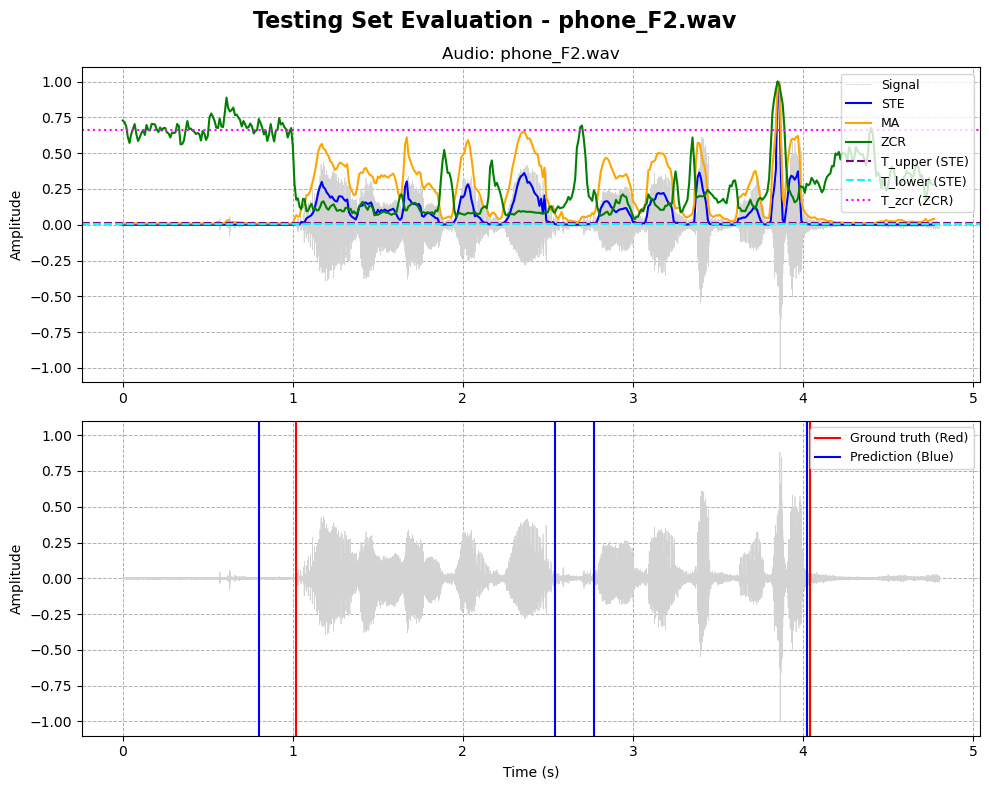

**Evaluation (phone_F2.wav):**

**Result:** Highly inaccurate (Severe False Negatives).

**Location:** The blue prediction lines completely miss the speech segments occurring in the second half of the audio (from 2.5s to 4.5s).

**Reason:** Because the speaker's volume is too low, the blue STE curve never crosses the strict purple `T_upper` line, meaning the state machine is never triggered.

---

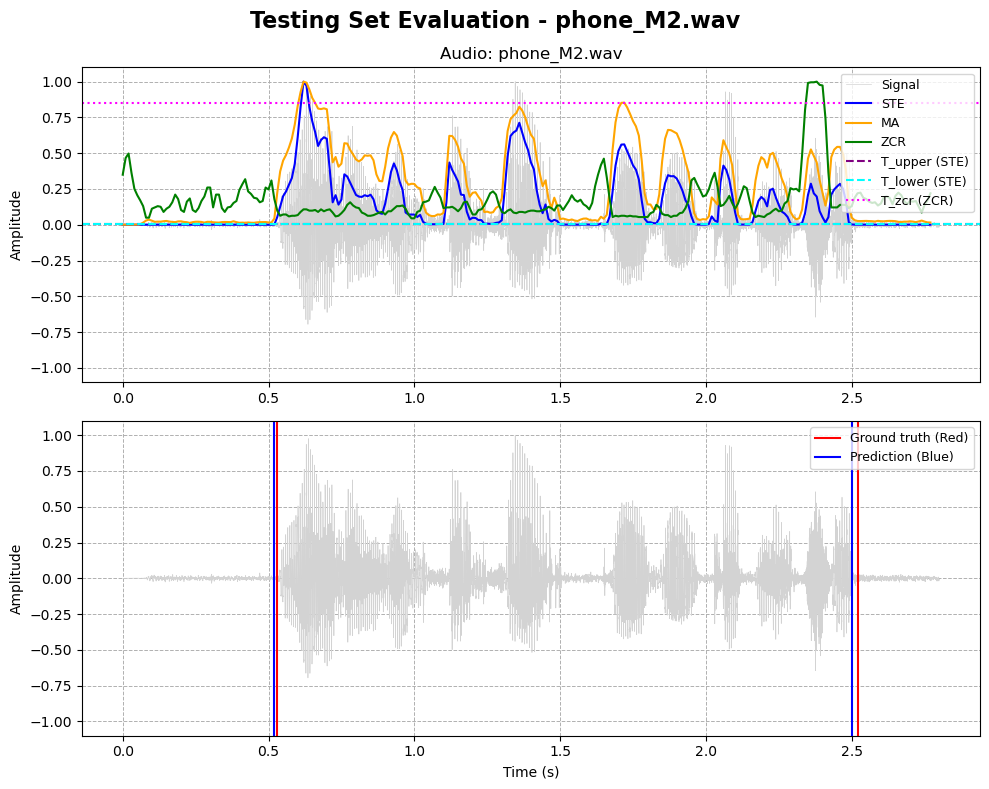

**Evaluation (phone_M2.wav):**

**Result:** Generally accurate.

**Location:** The blue prediction boundaries closely align with the red ground truth lines throughout the entire file.

**Reason:** The volume and noise floor of this specific file closely match the average statistics computed during the training phase, allowing the static thresholds to act effectively.

---

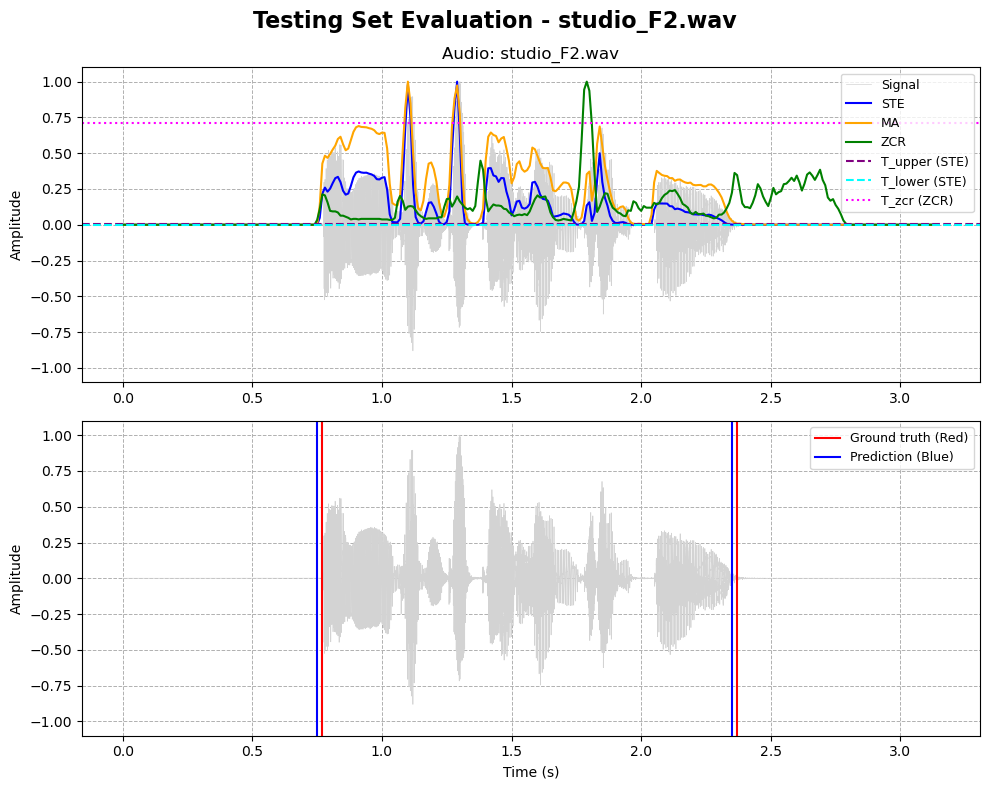

**Evaluation (studio_F2.wav):**

**Result:** Slightly inaccurate (False Positives).

**Location:** The blue prediction boundaries trigger slightly early and end slightly late.

**Reason:** The resting background noise floor in this recording is louder than the training average, causing standard ambient noise to frequently cross the lower cyan `T_lower` threshold and stretch the boundaries outward.

---

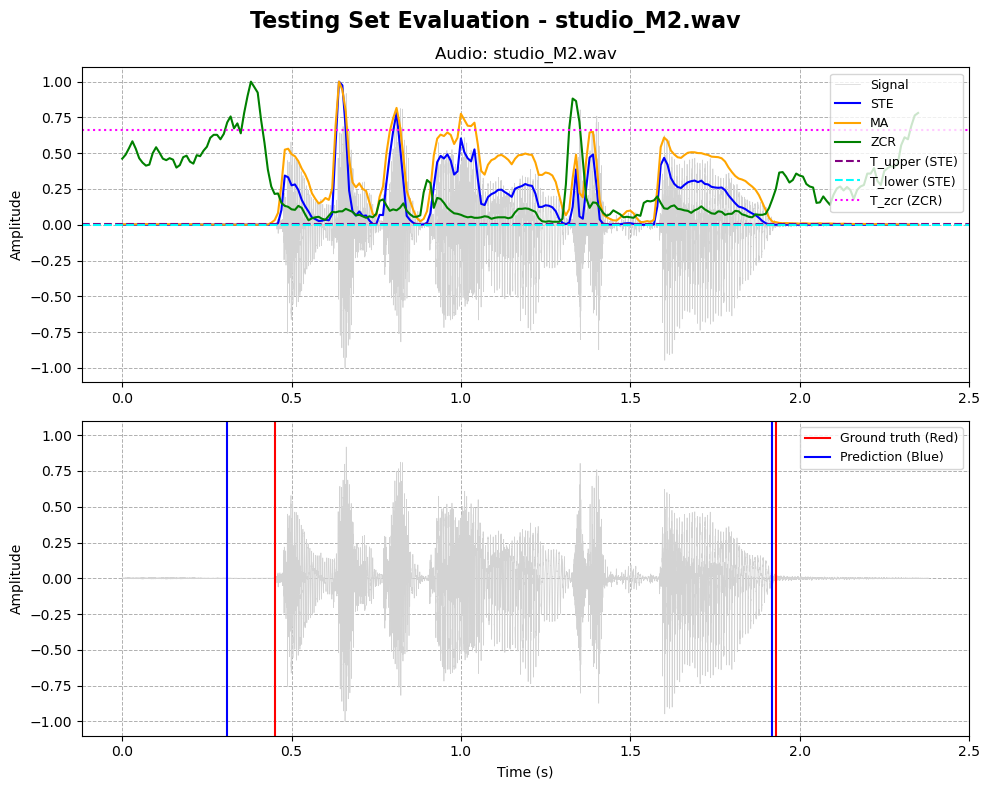

**Evaluation (studio_M2.wav):**

**Result:** Slightly inaccurate (Boundary stretching).

**Location:** Similar to studio_F2.wav, the blue boundaries are wider than the red ground truth lines.

**Reason:** The background electronic hiss generates a naturally high Zero-Crossing Rate. The algorithm mistakes this resting background noise for unvoiced consonants, falsely stretching the boundaries past the magenta `T_zcr` threshold.

---

In [5]:
# Directories for Phase 1 (Training)
train_audio = [
    "TinHieuHuanLuyen/phone_F1.wav",
    "TinHieuHuanLuyen/phone_M1.wav",
    "TinHieuHuanLuyen/studio_F1.wav",
    "TinHieuHuanLuyen/studio_M1.wav"
]
train_lab = [
    "TinHieuHuanLuyen/phone_F1.lab",
    "TinHieuHuanLuyen/phone_M1.lab",
    "TinHieuHuanLuyen/studio_F1.lab",
    "TinHieuHuanLuyen/studio_M1.lab"
]

# Directories for Phase 2 (Testing)
test_audio = [
    "TinHieuKiemThu/phone_F2.wav",
    "TinHieuKiemThu/phone_M2.wav",
    "TinHieuKiemThu/studio_F2.wav",
    "TinHieuKiemThu/studio_M2.wav"
]
test_lab = [
    "TinHieuKiemThu/phone_F2.lab",
    "TinHieuKiemThu/phone_M2.lab",
    "TinHieuKiemThu/studio_F2.lab",
    "TinHieuKiemThu/studio_M2.lab"
]

print("Phase 1: Analyzing Training Set to Calculate Thresholds...")
all_sil_ste, all_sil_zcr, all_speech_ste = [], [], []
frame_step_seconds = FRAME_STEP / 1000.0

# Phase 1 Loop: Extract features from the training set.
# Use the ground truth labels to mask out speech, isolating only the silent segments.
# Aggregate all silence STE and ZCR values across all training files into a single master pool.
for wav_path, lab_path in zip(train_audio, train_lab):
    full_wav = os.path.join(parent_dir, wav_path)
    full_lab = os.path.join(parent_dir, lab_path)
    
    SignalNormalized, SampleRate, _ = readAudio(full_wav)
    Frames = frameWindow(SignalNormalized, SampleRate)
    STE = calculate_STE(Frames)
    ZCR = calculate_ZCR(Frames)
    true_boundaries = read_lab_boundaries(full_lab)
    
    mask = get_groundtruth_mask(true_boundaries, len(STE), frame_step_seconds)
    all_sil_ste.extend(STE[~mask])
    all_sil_zcr.extend(ZCR[~mask])
    all_speech_ste.extend(STE[mask])

# Calculate the mean and standard deviation for the aggregated silence data.
# Formulate the three fixed global thresholds mathematically.
mu_sil_ste = np.mean(all_sil_ste)
std_sil_ste = np.std(all_sil_ste)
mu_sil_zcr = np.mean(all_sil_zcr)
std_sil_zcr = np.std(all_sil_zcr)

T_lower = mu_sil_ste + 2 * std_sil_ste
T_upper = mu_sil_ste + 5 * std_sil_ste
T_zcr = mu_sil_zcr + 2 * std_sil_zcr

print("Phase 2: Applying Algorithm to Testing Set...")
TimeAxes, NormalizedSignals, FrameTimeAxes = [], [], []
STEs, MAs, ZCRs, TrueBoundariesList, PredBoundariesList, Titles = [], [], [], [], [], []
evaluation_results = {}

# Phase 2 Loop: Evaluate the unseen testing files.
# Extract features and pass them to the pipeline alongside the globally locked thresholds.
# Store all temporal, feature, and boundary data in lists to pass to the graphing function.
for wav_path, lab_path in zip(test_audio, test_lab):
    full_wav = os.path.join(parent_dir, wav_path)
    full_lab = os.path.join(parent_dir, lab_path)
    filename = full_wav.split(os.sep)[-1]
    
    SignalNormalized, SampleRate, TimeAxis = readAudio(full_wav)
    Frames = frameWindow(SignalNormalized, SampleRate)
    STE = calculate_STE(Frames)
    MA = calculate_MA(Frames)
    ZCR = calculate_ZCR(Frames)
    FrameTimeAxis = np.arange(len(Frames)) * frame_step_seconds
    
    true_boundaries = read_lab_boundaries(full_lab)
    
    pred_boundaries = apply_vad_pipeline(STE, ZCR, T_upper, T_lower, T_zcr, frame_step_seconds)
    
    evaluation_results[filename] = {'true': true_boundaries, 'pred': pred_boundaries}
    Titles.append(filename)
    TimeAxes.append(TimeAxis)
    NormalizedSignals.append(SignalNormalized)
    FrameTimeAxes.append(FrameTimeAxis)
    STEs.append(STE)
    MAs.append(MA)
    ZCRs.append(ZCR)
    TrueBoundariesList.append(true_boundaries)
    PredBoundariesList.append(pred_boundaries)

# Output numerical evaluation to the console, and launch the visual plot.
print("="*60)
evaluate_and_print_terminal(evaluation_results, T_upper, T_lower, T_zcr)

plotFinalFigure(
    TimeAxes, NormalizedSignals, FrameTimeAxes, 
    STEs, MAs, ZCRs, TrueBoundariesList, PredBoundariesList, Titles, T_upper, T_lower, T_zcr
)